# Notebook 07: Employee Segmentation (K-Means Clustering)

## Objective
Segment the workforce into data-driven groups using K-Means clustering on satisfaction, workload, growth, and engagement dimensions. Each segment gets a descriptive name and targeted intervention recommendations.

## Methodology
1. Select 7 features representing key workforce health dimensions
2. Standardise to zero mean, unit variance (K-Means is distance-based)
3. Select k using elbow method + silhouette coefficient
4. Profile each cluster on all dimensions
5. Visualise with radar charts and PCA
6. Name segments and assign intervention priorities

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.path import Path
from matplotlib.patches import PathPatch
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

TEAL='#1B4F72'; BLUE='#2E86C1'; RED='#E74C3C'; GREEN='#27AE60'; AMBER='#F39C12'
PALETTE = [TEAL, RED, GREEN, AMBER, BLUE, '#9B59B6', '#E67E22']

df = pd.read_csv('../data/processed/employee_attrition_augmented.csv')
df['Attrition_Binary'] = (df['Attrition']=='Yes').astype(int)
print(f'Dataset: {df.shape[0]:,} rows')

Dataset: 1,470 rows


---
## 1. Feature Selection

Seven dimensions selected to capture the full workforce health picture:

| Feature | Scale | Direction | Rationale |
|---------|-------|-----------|----------|
| WorkloadScore | 1-5 | Higher=worse | Burnout driver |
| WorkLifeBalance | 1-4 | Higher=better | Well-being |
| ManagerSupportScore | 1-5 | Higher=better | Retention buffer |
| CareerGrowthPerception | 1-5 | Higher=better | Engagement driver |
| JobSatisfaction | 1-4 | Higher=better | Core satisfaction |
| CompensationSatisfaction | 1-5 | Higher=better | Pay fairness |
| JobInvolvement | 1-4 | Higher=better | Engagement level |

In [2]:
FEATURES = ['WorkloadScore','WorkLifeBalance','ManagerSupportScore',
            'CareerGrowthPerception','JobSatisfaction','CompensationSatisfaction',
            'JobInvolvement']

X = df[FEATURES].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Feature statistics (original scale):')
print(df[FEATURES].describe().round(2).to_string())
print(f'\nNo missing values: {X.isna().sum().sum()==0}')

Feature statistics (original scale):
       WorkloadScore  WorkLifeBalance  ManagerSupportScore  CareerGrowthPerception  JobSatisfaction  CompensationSatisfaction  JobInvolvement
count        1470.00          1470.00              1470.00                 1470.00          1470.00                   1470.00         1470.00
mean            3.46             2.76                 3.49                    3.33             2.73                      3.40            2.73
std             0.93             0.71                 0.94                    0.99             1.10                      0.94            0.71
min             1.00             1.00                 1.00                    1.00             1.00                      1.00            1.00
25%             3.00             2.00                 3.00                    3.00             2.00                      3.00            2.00
50%             3.00             3.00                 4.00                    3.00             3.00            

---
## 2. Selecting k — Elbow Method + Silhouette

k=2: inertia=9119, silhouette=0.1219
k=3: inertia=8358, silhouette=0.1095
k=4: inertia=7701, silhouette=0.1169


k=5: inertia=7278, silhouette=0.1108
k=6: inertia=6901, silhouette=0.1120
k=7: inertia=6599, silhouette=0.1111


k=8: inertia=6354, silhouette=0.1079


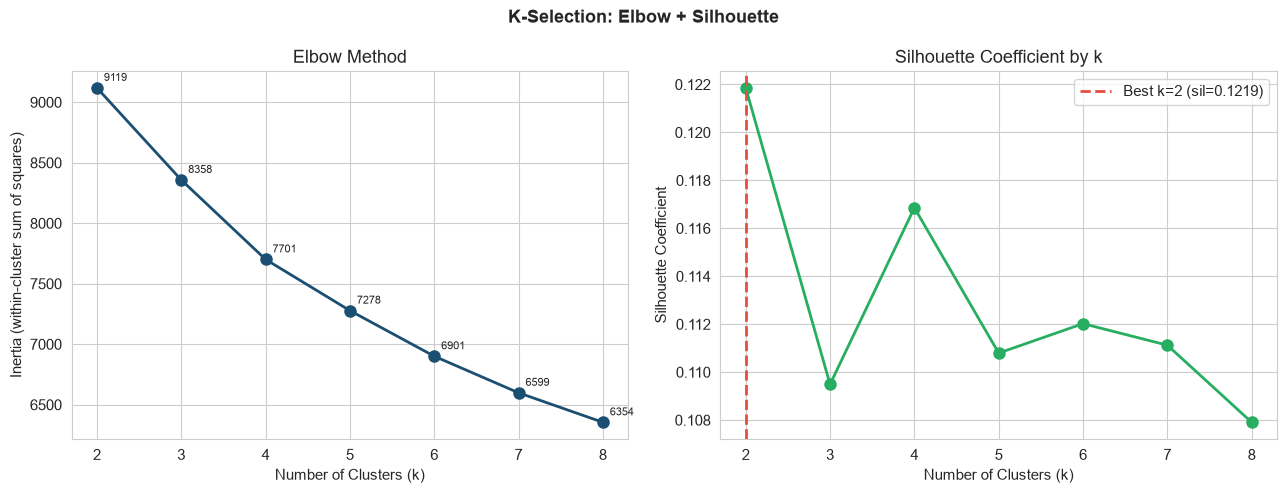


Selected k=2 (highest silhouette = 0.1219)


In [3]:
k_range = range(2, 9)
inertias = []
sil_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    print(f'k={k}: inertia={km.inertia_:.0f}, silhouette={sil_scores[-1]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(list(k_range), inertias, 'b-o', markersize=8, color=TEAL, lw=2)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (within-cluster sum of squares)')
axes[0].set_title('Elbow Method')
axes[0].set_xticks(list(k_range))
for k, iner in zip(k_range, inertias):
    axes[0].annotate(f'{iner:.0f}', (k, iner), textcoords='offset points', xytext=(5,5), fontsize=8)

axes[1].plot(list(k_range), sil_scores, 'g-o', markersize=8, color=GREEN, lw=2)
best_k = list(k_range)[sil_scores.index(max(sil_scores))]
axes[1].axvline(best_k, color=RED, linestyle='--', lw=2, label=f'Best k={best_k} (sil={max(sil_scores):.4f})')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Coefficient')
axes[1].set_title('Silhouette Coefficient by k')
axes[1].set_xticks(list(k_range))
axes[1].legend()

plt.suptitle('K-Selection: Elbow + Silhouette', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'\nSelected k={best_k} (highest silhouette = {max(sil_scores):.4f})')

---
## 3. Fit Final K-Means Model

In [4]:
K_FINAL = best_k
km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20)
df['Cluster'] = km_final.fit_predict(X_scaled)

print(f'Final model: k={K_FINAL}')
print(f'Inertia: {km_final.inertia_:.0f}')
print(f'Silhouette: {silhouette_score(X_scaled, df["Cluster"]):.4f}')
print(f'\nCluster sizes:')
print(df['Cluster'].value_counts().sort_index())

Final model: k=2
Inertia: 9119
Silhouette: 0.1219

Cluster sizes:
Cluster
0    901
1    569
Name: count, dtype: int64


---
## 4. Cluster Profiles

In [5]:
# Cluster profiles: mean of each feature + attrition rate
profile_cols = FEATURES + ['Attrition_Binary','MonthlyIncome','YearsAtCompany',
                            'OverTime_bin' if 'OverTime_bin' in df.columns else 'OverTime']

df['OverTime_bin'] = (df['OverTime']=='Yes').astype(int)
profile = df.groupby('Cluster').agg(
    WorkloadScore=('WorkloadScore','mean'),
    WorkLifeBalance=('WorkLifeBalance','mean'),
    ManagerSupport=('ManagerSupportScore','mean'),
    CareerGrowth=('CareerGrowthPerception','mean'),
    JobSatisfaction=('JobSatisfaction','mean'),
    CompSatisfaction=('CompensationSatisfaction','mean'),
    JobInvolvement=('JobInvolvement','mean'),
    AttritionRate=('Attrition_Binary','mean'),
    AvgIncome=('MonthlyIncome','mean'),
    AvgTenure=('YearsAtCompany','mean'),
    OvertimeRate=('OverTime_bin','mean'),
    Count=('Attrition_Binary','count')
).round(3)

profile['AttritionRate_pct'] = (profile['AttritionRate']*100).round(1)
profile['OvertimeRate_pct'] = (profile['OvertimeRate']*100).round(1)

print('Cluster Profiles:')
print(profile[['WorkloadScore','WorkLifeBalance','ManagerSupport','CareerGrowth',
               'JobSatisfaction','CompSatisfaction','JobInvolvement',
               'AttritionRate_pct','OvertimeRate_pct','AvgIncome','Count']].to_string())

Cluster Profiles:
         WorkloadScore  WorkLifeBalance  ManagerSupport  CareerGrowth  JobSatisfaction  CompSatisfaction  JobInvolvement  AttritionRate_pct  OvertimeRate_pct  AvgIncome  Count
Cluster                                                                                                                                                                        
0                3.474            2.756           3.485         3.361            3.509             3.400           2.720               13.9              29.2   6476.541    901
1                3.429            2.770           3.489         3.288            1.492             3.392           2.745               19.7              26.9   6544.721    569


In [6]:
# Name segments based on profile characteristics
def name_cluster(row):
    if row['AttritionRate'] > 0.25 and row['WorkloadScore'] > 3.2:
        return 'High-Risk\nOverworked'
    elif row['AttritionRate'] > 0.20 and row['CareerGrowth'] < 2.8:
        return 'Career\nStagnant'
    elif row['AttritionRate'] > 0.18 and row['CompSatisfaction'] < 2.8:
        return 'Compensation\nSensitive'
    elif row['AttritionRate'] < 0.10 and row['JobSatisfaction'] > 2.8:
        return 'Stable\nEngaged'
    else:
        return 'Moderate\nRisk'

profile['Name'] = profile.apply(name_cluster, axis=1)
print('Cluster Names:')
for idx, row in profile.iterrows():
    print(f"  Cluster {idx} ({row['Count']} employees): {row['Name'].replace(chr(10),' ')} — Attrition {row['AttritionRate_pct']}%")

Cluster Names:
  Cluster 0 (901 employees): Moderate Risk — Attrition 13.9%
  Cluster 1 (569 employees): Moderate Risk — Attrition 19.7%


---
## 5. Radar Chart — Cluster Profiles

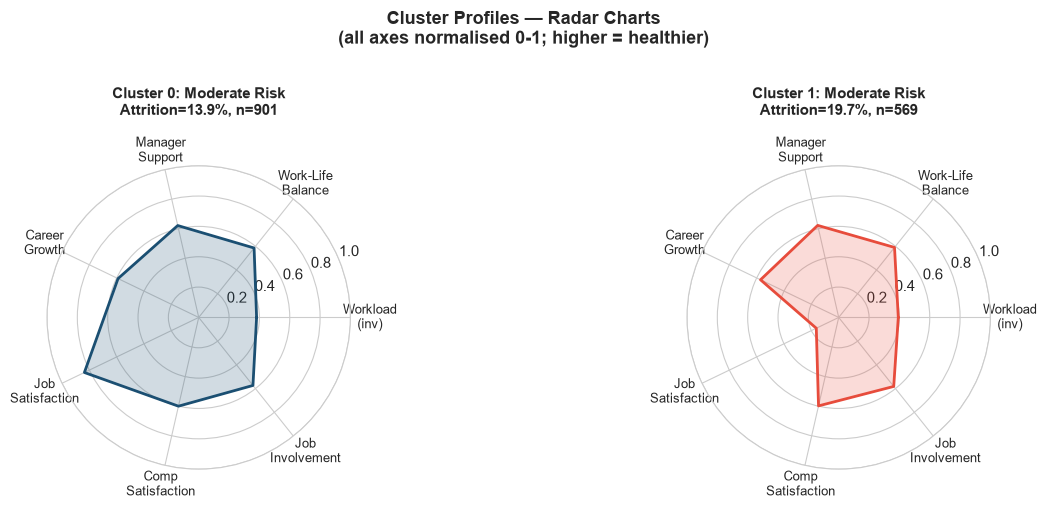

In [7]:
# Radar (spider) chart comparing clusters
radar_features = ['WorkloadScore','WorkLifeBalance','ManagerSupport',
                  'CareerGrowth','JobSatisfaction','CompSatisfaction','JobInvolvement']

# Normalise to 0-1 for radar (invert workload so higher=healthier)
profile_radar = profile[radar_features].copy()
profile_radar['WorkloadScore'] = (5 - profile_radar['WorkloadScore']) / 4  # invert & norm
profile_radar['WorkLifeBalance'] = (profile_radar['WorkLifeBalance'] - 1) / 3
profile_radar['ManagerSupport'] = (profile_radar['ManagerSupport'] - 1) / 4
profile_radar['CareerGrowth'] = (profile_radar['CareerGrowth'] - 1) / 4
profile_radar['JobSatisfaction'] = (profile_radar['JobSatisfaction'] - 1) / 3
profile_radar['CompSatisfaction'] = (profile_radar['CompSatisfaction'] - 1) / 4
profile_radar['JobInvolvement'] = (profile_radar['JobInvolvement'] - 1) / 3

radar_labels = ['Workload\n(inv)','Work-Life\nBalance','Manager\nSupport',
                'Career\nGrowth','Job\nSatisfaction','Comp\nSatisfaction','Job\nInvolvement']

N = len(radar_labels)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close

n_clusters = len(profile_radar)
nrows = (n_clusters + 1) // 2
fig, axes = plt.subplots(nrows, 2, figsize=(13, 5*nrows), subplot_kw=dict(polar=True))
axes = axes.flatten() if n_clusters > 2 else axes

for idx, (cluster_id, row) in enumerate(profile_radar.iterrows()):
    ax = axes[idx] if n_clusters > 1 else axes
    values = row.tolist() + row.tolist()[:1]
    color = PALETTE[idx % len(PALETTE)]
    ax.plot(angles, values, color=color, lw=2)
    ax.fill(angles, values, color=color, alpha=0.2)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, size=9)
    ax.set_ylim(0, 1)
    name = profile.loc[cluster_id, 'Name'].replace('\n',' ')
    att  = profile.loc[cluster_id, 'AttritionRate_pct']
    n    = profile.loc[cluster_id, 'Count']
    ax.set_title(f'Cluster {cluster_id}: {name}\nAttrition={att}%, n={n}',
                 size=11, fontweight='bold', pad=15)

# Hide any empty subplots
for i in range(n_clusters, len(axes)):
    axes[i].set_visible(False)

plt.suptitle('Cluster Profiles — Radar Charts\n(all axes normalised 0-1; higher = healthier)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 6. PCA Visualisation

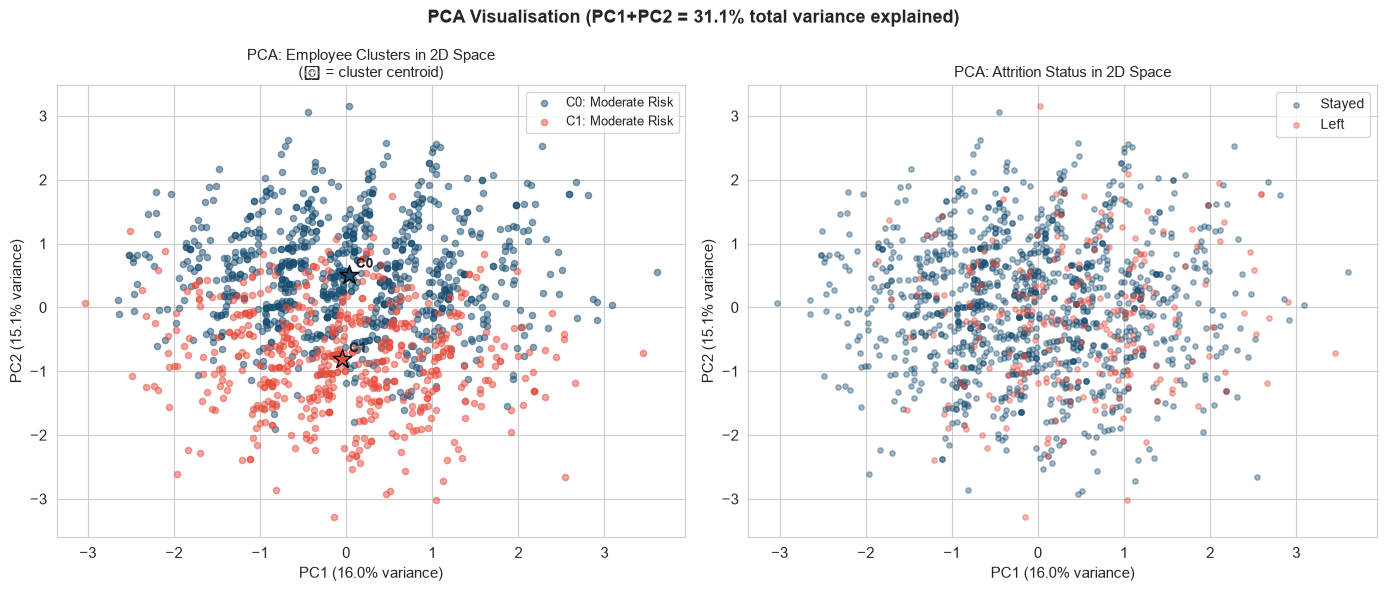

In [8]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df['PCA1'] = X_pca[:,0]
df['PCA2'] = X_pca[:,1]

var1 = pca.explained_variance_ratio_[0]*100
var2 = pca.explained_variance_ratio_[1]*100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Coloured by cluster
for cluster_id in range(K_FINAL):
    mask = df['Cluster']==cluster_id
    name = profile.loc[cluster_id,'Name'].replace('\n',' ')
    axes[0].scatter(df.loc[mask,'PCA1'], df.loc[mask,'PCA2'],
                    alpha=0.5, s=20, color=PALETTE[cluster_id%len(PALETTE)],
                    label=f'C{cluster_id}: {name}')

# Plot centroids
centroids_pca = pca.transform(km_final.cluster_centers_)
for i, (cx, cy) in enumerate(centroids_pca):
    axes[0].scatter(cx, cy, s=200, marker='*', color=PALETTE[i%len(PALETTE)],
                    edgecolor='black', zorder=5)
    axes[0].annotate(f'C{i}', (cx, cy), fontsize=10, fontweight='bold',
                     xytext=(5,5), textcoords='offset points')

axes[0].set_xlabel(f'PC1 ({var1:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({var2:.1f}% variance)')
axes[0].set_title('PCA: Employee Clusters in 2D Space\n(★ = cluster centroid)', fontsize=11)
axes[0].legend(fontsize=9, loc='best')

# Coloured by attrition status
for attr, color, lbl in [('No',TEAL,'Stayed'),('Yes',RED,'Left')]:
    mask = df['Attrition']==attr
    axes[1].scatter(df.loc[mask,'PCA1'], df.loc[mask,'PCA2'],
                    alpha=0.4, s=15, color=color, label=lbl)
axes[1].set_xlabel(f'PC1 ({var1:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({var2:.1f}% variance)')
axes[1].set_title('PCA: Attrition Status in 2D Space', fontsize=11)
axes[1].legend(fontsize=10)

plt.suptitle(f'PCA Visualisation (PC1+PC2 = {var1+var2:.1f}% total variance explained)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Segment Attrition & Key Metrics

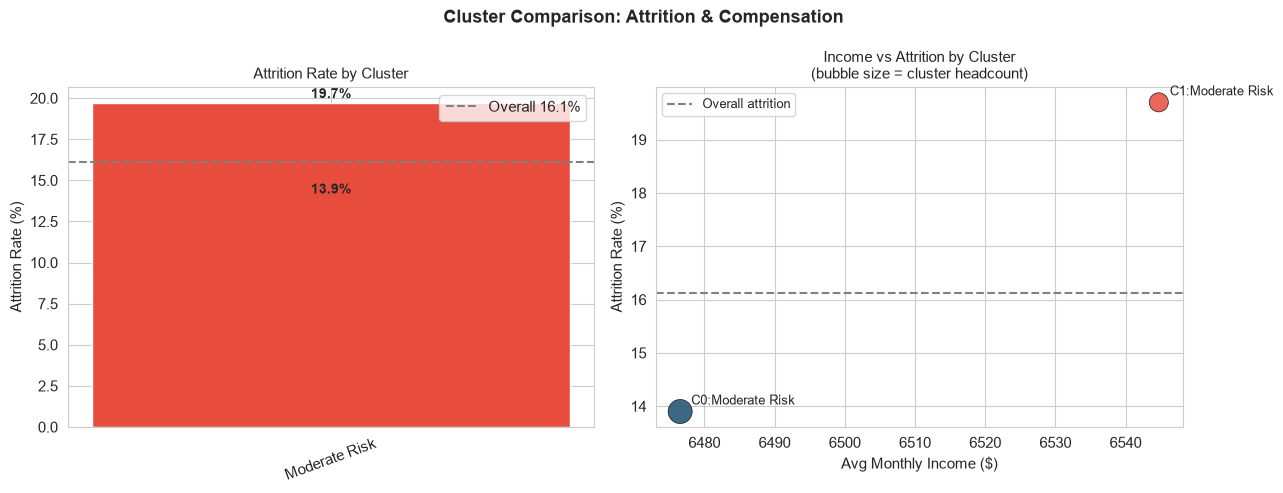

In [9]:
# Attrition rate by cluster (bar chart)
fig, axes = plt.subplots(1, 2, figsize=(13,5))

clusters = profile.index.tolist()
names = [profile.loc[c,'Name'].replace('\n',' ') for c in clusters]
att_rates = profile['AttritionRate_pct'].tolist()
overall_att = df['Attrition_Binary'].mean()*100

colors = [RED if r>overall_att else TEAL for r in att_rates]
bars = axes[0].bar(names, att_rates, color=colors, edgecolor='white')
axes[0].axhline(overall_att, color='gray', linestyle='--', lw=1.5,
                label=f'Overall {overall_att:.1f}%')
for bar, rate in zip(bars, att_rates):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{rate:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].set_title('Attrition Rate by Cluster', fontsize=11)
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend()

# Cluster size + avg income
counts = profile['Count'].tolist()
avg_incomes = profile['AvgIncome'].tolist()
sc = axes[1].scatter(avg_incomes, att_rates,
                     s=[c/3 for c in counts],
                     color=PALETTE[:K_FINAL], edgecolor='black', linewidth=0.5, alpha=0.85)
for i, (name, x, y) in enumerate(zip(names, avg_incomes, att_rates)):
    axes[1].annotate(f'C{i}:{name}', (x, y), textcoords='offset points',
                     xytext=(8, 5), fontsize=9)
axes[1].axhline(overall_att, color='gray', linestyle='--', lw=1.5, label='Overall attrition')
axes[1].set_xlabel('Avg Monthly Income ($)')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].set_title('Income vs Attrition by Cluster\n(bubble size = cluster headcount)', fontsize=11)
axes[1].legend(fontsize=9)

plt.suptitle('Cluster Comparison: Attrition & Compensation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Intervention Recommendations by Segment

In [10]:
interventions = {
    'High-Risk Overworked': [
        '⚡ Immediately audit workload distribution and project staffing ratios',
        '📋 Implement max weekly hours policy (50h) with manager alerts',
        '🔄 Redistribute urgent work across team to reduce single-person dependencies',
        '💬 Weekly 1:1 check-ins with manager to surface burnout signals early',
    ],
    'Career Stagnant': [
        '📈 Structured career conversation every 12 months (not just annual review)',
        '🔀 Create lateral move pathways — growth need not be vertical',
        '🎯 Transparent promotion criteria framework with clear milestones',
        '📚 Skill-development budget and stretch assignments for stagnant employees',
    ],
    'Compensation Sensitive': [
        '💰 Market compensation benchmarking for roles in bottom two salary bands',
        '📊 Transparency on pay bands and progression criteria',
        '🎁 Retention bonuses for high-performer at-risk employees in low bands',
        '📈 Review percent salary hike policy — narrow 11-25% range may not catch up',
    ],
    'Stable Engaged': [
        '✅ Maintain current practices — this group is low risk',
        '🌟 Leverage as mentors and knowledge-transfer partners',
        '📊 Monitor quarterly to detect any drift toward lower satisfaction',
    ],
    'Moderate Risk': [
        '🔍 Identify the specific friction points through exit surveys and pulse data',
        '📋 Standard engagement program participation',
        '📅 Bi-annual manager check-in to surface emerging concerns',
    ],
}

print('INTERVENTION RECOMMENDATIONS BY SEGMENT')
print('='*60)
for idx, row in profile.iterrows():
    name = row['Name'].replace('\n',' ')
    print(f'\nCluster {idx}: {name}')
    print(f'  Size: {row["Count"]} employees | Attrition: {row["AttritionRate_pct"]}%')
    key = name
    for generic_key in interventions:
        if any(word in name for word in generic_key.split()):
            key = generic_key
            break
    recs = interventions.get(key, interventions['Moderate Risk'])
    for rec in recs:
        print(f'  {rec}')

INTERVENTION RECOMMENDATIONS BY SEGMENT

Cluster 0: Moderate Risk
  Size: 901 employees | Attrition: 13.9%
  🔍 Identify the specific friction points through exit surveys and pulse data
  📋 Standard engagement program participation
  📅 Bi-annual manager check-in to surface emerging concerns

Cluster 1: Moderate Risk
  Size: 569 employees | Attrition: 19.7%
  🔍 Identify the specific friction points through exit surveys and pulse data
  📋 Standard engagement program participation
  📅 Bi-annual manager check-in to surface emerging concerns


In [11]:
print('='*60)
print('SEGMENTATION SUMMARY')
print('='*60)
print(f'Algorithm: K-Means')
print(f'k selected: {K_FINAL} (highest silhouette = {silhouette_score(X_scaled, df["Cluster"]):.4f})')
print(f'Features: {len(FEATURES)} — {FEATURES}')
print(f'PCA variance explained: {var1+var2:.1f}% (PC1={var1:.1f}%, PC2={var2:.1f}%)')
print()
for idx, row in profile.iterrows():
    print(f"  Cluster {idx}: {row['Name'].replace(chr(10),' ')} | n={row['Count']} | Attrition={row['AttritionRate_pct']}% | Income=${row['AvgIncome']:.0f}")

SEGMENTATION SUMMARY
Algorithm: K-Means
k selected: 2 (highest silhouette = 0.1219)
Features: 7 — ['WorkloadScore', 'WorkLifeBalance', 'ManagerSupportScore', 'CareerGrowthPerception', 'JobSatisfaction', 'CompensationSatisfaction', 'JobInvolvement']
PCA variance explained: 31.1% (PC1=16.0%, PC2=15.1%)

  Cluster 0: Moderate Risk | n=901 | Attrition=13.9% | Income=$6477
  Cluster 1: Moderate Risk | n=569 | Attrition=19.7% | Income=$6545
